# Performance Testing

## ideas
- general statistical methods for evaluation
- downstream task: train two models and use real data as validation set

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, wasserstein_distance
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


: 

In [22]:
real = pd.read_csv("datasets/filtered.csv", engine="pyarrow")
synth = pd.read_csv("output/output.csv", engine="pyarrow")

In [23]:
numeric_cols = real.select_dtypes(include=np.number).columns.intersection(
    synth.select_dtypes(include=np.number).columns
)

selected_cols = [
    'st_dirs',
    'st_successful',
    'st_failed',
    'st_expired',
    'st_canceled',
    'st_bytes_xfered',
    'st_faults',
    'st_xfer_time_ms'
]

# Ensure both datasets contain these columns
real = real[selected_cols].dropna()
synth = synth[selected_cols].dropna()

print(f"Validating {len(selected_cols)} transfer-related features.\n")

Validating 8 transfer-related features.



In [24]:
stats_real = real.describe().T[['mean', 'std', 'min', 'max']]
stats_synth = synth.describe().T[['mean', 'std', 'min', 'max']]

In [25]:
summary = pd.concat(
    [stats_real.add_suffix('_real'), stats_synth.add_suffix('_synth')],
    axis=1
)
print("Descriptive statistics (real vs synthetic):")
print(summary)

Descriptive statistics (real vs synthetic):
                    mean_real      std_real  min_real      max_real  \
st_dirs          3.165675e+02  3.371757e+04       0.0  8.791225e+07   
st_successful    4.519742e+03  2.529234e+05       0.0  5.114859e+08   
st_failed        4.972352e+01  5.160599e+04       0.0  1.440816e+08   
st_expired       5.304780e+02  1.934975e+05       0.0  4.457491e+08   
st_canceled      9.686416e+02  1.760280e+05       0.0  2.807579e+08   
st_bytes_xfered  5.600996e+10  2.698348e+12       0.0  7.802815e+15   
st_faults        5.122567e+00  7.664199e+01       0.0  1.182540e+05   
st_xfer_time_ms  8.983515e+05  1.889429e+07       0.0  1.482032e+10   

                   mean_synth     std_synth  min_synth     max_synth  
st_dirs          1.147233e+00  3.404669e+01        0.0  8.788200e+04  
st_successful    2.976347e+07  7.613150e+10        0.0  2.706133e+14  
st_failed        9.952825e-05  1.150636e-02        0.0  1.100000e+01  
st_expired       3.841865e-02  1

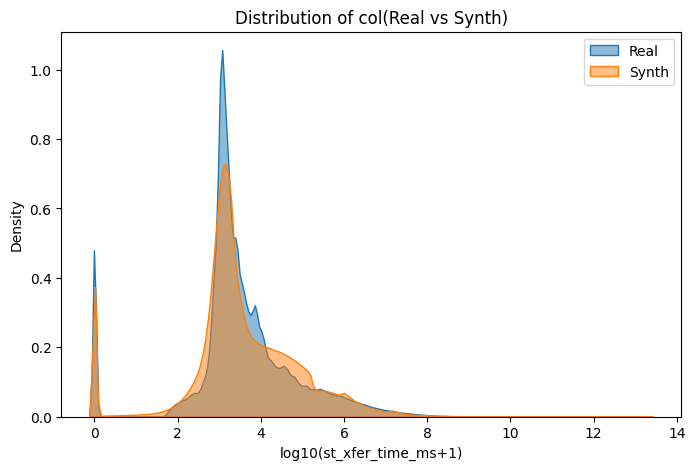

In [10]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
 
# Plot the distributions
col = "st_xfer_time_ms"
plt.figure(figsize=(8, 5))

real_log = np.log10(real[col].clip(lower=1))
synth_log = np.log10(synth[col].clip(lower=1))

sns.kdeplot(real_log, label="Real", fill=True, alpha=0.5)

sns.kdeplot(synth_log, label="Synth", fill=True, alpha=0.5)
 
plt.title("Distribution of col(Real vs Synth)")

plt.xlabel(f'log10({col}+1)')

plt.ylabel("Density")

plt.legend()

plt.show()



In [26]:
ks_results, wd_results = {}, {}
for col in selected_cols:
    ks = ks_2samp(real[col], synth[col]).statistic
    wd = wasserstein_distance(real[col], synth[col])
    ks_results[col] = ks
    wd_results[col] = wd

ks_df = pd.DataFrame({'KS_stat': ks_results, 'Wasserstein': wd_results})
print("\nDistribution similarity (lower is better):")
print(ks_df.sort_values('KS_stat'))


Distribution similarity (lower is better):
                  KS_stat   Wasserstein
st_failed        0.000147  4.972342e+01
st_expired       0.002094  5.304396e+02
st_canceled      0.010137  9.685891e+02
st_faults        0.020317  4.965506e+00
st_dirs          0.053102  3.154203e+02
st_xfer_time_ms  0.061996  2.988118e+08
st_bytes_xfered  0.065531  1.666999e+12
st_successful    0.073751  2.976192e+07


In [17]:
# Should this be included in the code?

synth.loc[synth["st_bytes_xfered"] > real["st_bytes_xfered"].max(), "st_bytes_xfered"] = real["st_bytes_xfered"].max()
synth.loc[synth["st_xfer_time_ms"] > real["st_xfer_time_ms"].max(), "st_xfer_time_ms"] = real["st_xfer_time_ms"].max()

In [27]:
print("real")
print(np.percentile(real.st_bytes_xfered, 99))
print(np.percentile(real.st_bytes_xfered, 95))
print(np.percentile(real.st_bytes_xfered, 90))
print("synth")
print(np.percentile(synth.st_bytes_xfered, 99))
print(np.percentile(synth.st_bytes_xfered, 95))
print(np.percentile(synth.st_bytes_xfered, 90))


real
559270485228.0292
35716142276.899826
6277237687.3
synth
559270180152.2064
35716139914.62927
6277237687.3


In [28]:
print("real")
print(np.percentile(real.st_xfer_time_ms, 99))
print(np.percentile(real.st_xfer_time_ms, 95))
print(np.percentile(real.st_xfer_time_ms, 90))
print(np.percentile(real.st_xfer_time_ms, 50))
print(np.percentile(real.st_xfer_time_ms, 30))
print("synth")
print(np.percentile(synth.st_xfer_time_ms, 99))
print(np.percentile(synth.st_xfer_time_ms, 95))
print(np.percentile(synth.st_xfer_time_ms, 90))
print(np.percentile(synth.st_xfer_time_ms, 50))
print(np.percentile(synth.st_xfer_time_ms, 30))

real
12940297.489999995
882872.049999997
172722.0
2193.0
1188.0
synth
12940297.489999995
882872.049999997
172722.0
2193.0
1090.9438719449654


In [29]:
corr_real = real.corr()
corr_synth = synth.corr()

# Drop columns that annihilate correlation
zero_var = real.columns[(real.nunique() <= 1) | (synth.nunique() <= 1)]
real_corr_input = real.drop(columns=zero_var)
synth_corr_input = synth.drop(columns=zero_var)
corr_real = real_corr_input.corr()
corr_synth = synth_corr_input.corr()
corr_diff = np.linalg.norm(corr_real - corr_synth, 'fro')

corr_diff_matrix = (corr_real - corr_synth).abs()

# Flatten to pairs for readability
corr_diff_pairs = (
    corr_diff_matrix
    .where(np.triu(np.ones(corr_diff_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
corr_diff_pairs.columns = ['Feature1', 'Feature2', 'Abs_Diff']

# Sort by difference magnitude
corr_diff_pairs = corr_diff_pairs.sort_values('Abs_Diff', ascending=False)
print("Top correlation differences:")
print(corr_diff)
print(corr_diff_pairs.head(10))


Top correlation differences:
0.8985875120283885
           Feature1         Feature2  Abs_Diff
2           st_dirs       st_expired  0.342550
0           st_dirs    st_successful  0.334516
27        st_faults  st_xfer_time_ms  0.216379
3           st_dirs      st_canceled  0.214174
26  st_bytes_xfered  st_xfer_time_ms  0.189363
10    st_successful  st_bytes_xfered  0.103162
12    st_successful  st_xfer_time_ms  0.095055
9     st_successful      st_canceled  0.086783
20       st_expired        st_faults  0.075290
4           st_dirs  st_bytes_xfered  0.058959


## Downstream predictive test
Train regression models on real and synthetic data separately and compare how well they predict real held-out transfer times.

In [25]:
target_col = "st_xfer_time_ms"
feature_cols = [col for col in selected_cols if col != target_col]

X_real = real[feature_cols]
y_real = real[target_col]
X_synth = synth[feature_cols]
y_synth = synth[target_col]

X_train_real, X_holdout_real, y_train_real, y_holdout_real = train_test_split(
    X_real,
    y_real,
    test_size=0.2,
    random_state=42,
)


def subsample_xy(X, y, max_rows, seed):
    if max_rows is None or len(X) <= max_rows:
        return X, y
    sampled_idx = X.sample(n=max_rows, random_state=seed).index
    return X.loc[sampled_idx], y.loc[sampled_idx]


max_train_rows = 200_000
X_train_real_limited, y_train_real_limited = subsample_xy(
    X_train_real,
    y_train_real,
    max_train_rows,
    seed=0,
)
X_synth_limited, y_synth_limited = subsample_xy(
    X_synth,
    y_synth,
    max_train_rows,
    seed=1,
)


def fit_and_score(X_train, y_train, X_eval, y_eval, label):
    model = XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        objective="reg:squarederror",
        n_jobs=-1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    preds = model.predict(X_eval)
    return {
        "training_data": label,
        "train_rows": len(X_train),
        "r2": r2_score(y_eval, preds),
        "mae": mean_absolute_error(y_eval, preds),
        "rmse": mean_squared_error(y_eval, preds),
    }


results = [
    fit_and_score(
        X_train_real_limited,
        y_train_real_limited,
        X_holdout_real,
        y_holdout_real,
        "real",
    ),
    fit_and_score(
        X_synth_limited,
        y_synth_limited,
        X_holdout_real,
        y_holdout_real,
        "synthetic",
    ),
]

results_df = pd.DataFrame(results).set_index("training_data")
print(f"Downstream regression on {target_col} (evaluated on held-out real data):")
display(results_df)


Downstream regression on st_xfer_time_ms (evaluated on held-out real data):


,train_rows,r2,mae,rmse
training_data,,,,
real,200000,0.157338,9.944945e+05,3.062582e+14
synthetic,200000,-59.339706,6.713905e+06,2.192995e+16
